In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df=pd.read_csv('/content/drive/MyDrive/wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label','Alcohol','Malic acid']

In [5]:
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


### **Distplot plotting**

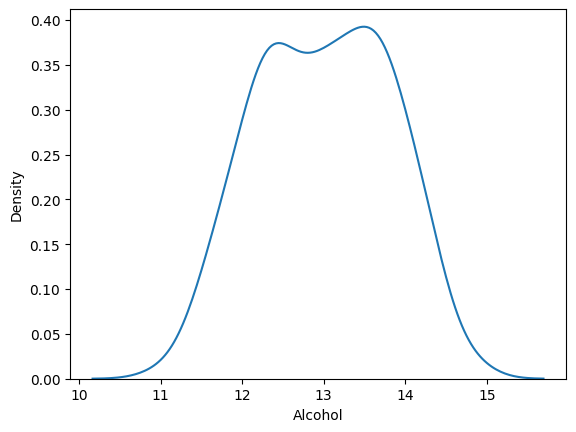

In [6]:
sns.kdeplot(df['Alcohol'])
plt.show()

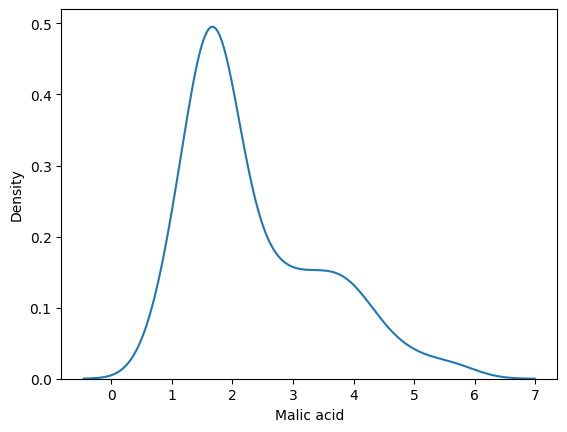

In [7]:
sns.kdeplot(df['Malic acid'])
plt.show()

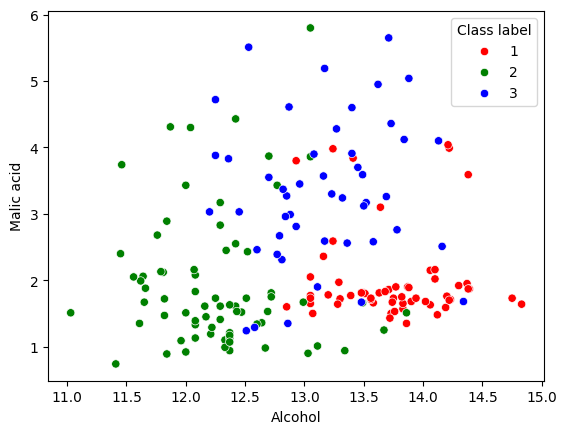

In [8]:
color_dict={1:'red',2:'green',3:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette=color_dict)
plt.show()

### **Scaling**

In [9]:
from sklearn.model_selection import train_test_split
train_X,test_X,train_Y,test_Y=train_test_split(df.drop('Class label',axis=1),df['Class label'],test_size=0.3,random_state=0)

In [10]:
train_X.shape,test_X.shape

((124, 2), (54, 2))

In [17]:
from sklearn.preprocessing import MinMaxScaler
Scaler=MinMaxScaler()
Scaler.fit(train_X)
X_trained_Scaled=Scaler.transform(train_X)
X_test_Scaled=Scaler.transform(test_X)

In [18]:
X_trained_Scaled=pd.DataFrame(X_trained_Scaled,columns=train_X.columns)
X_test_Scaled=pd.DataFrame(X_test_Scaled,columns=test_X.columns)

In [21]:
np.round(train_X.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [22]:
np.round(X_trained_Scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


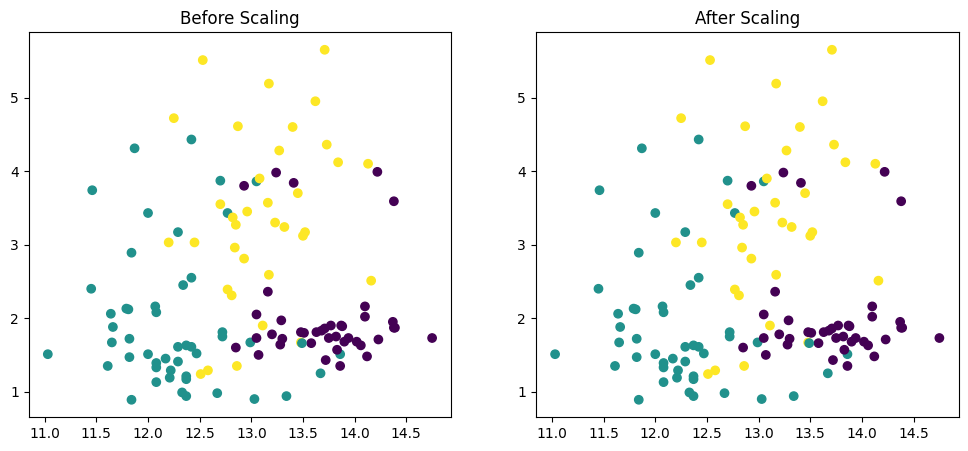

In [23]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(train_X['Alcohol'],train_X['Malic acid'],c=train_Y)
ax1.set_title('Before Scaling')
ax2.scatter(train_X['Alcohol'],train_X['Malic acid'],c=train_Y)
ax2.set_title('After Scaling')
plt.show()

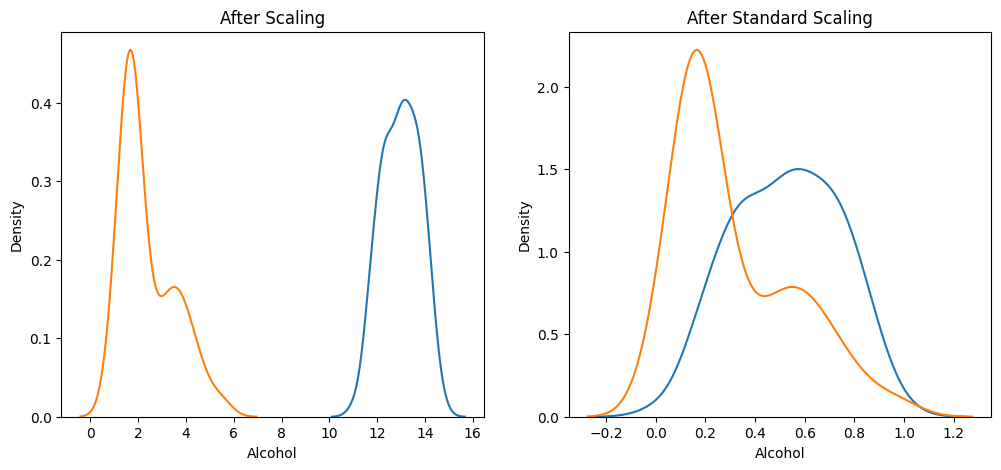

In [25]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(train_X['Alcohol'],ax=ax1)
sns.kdeplot(train_X['Malic acid'],ax=ax1)
ax1.set_title('After Scaling')

# After Scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_trained_Scaled['Alcohol'],ax=ax2)
sns.kdeplot(X_trained_Scaled['Malic acid'],ax=ax2)

plt.show()

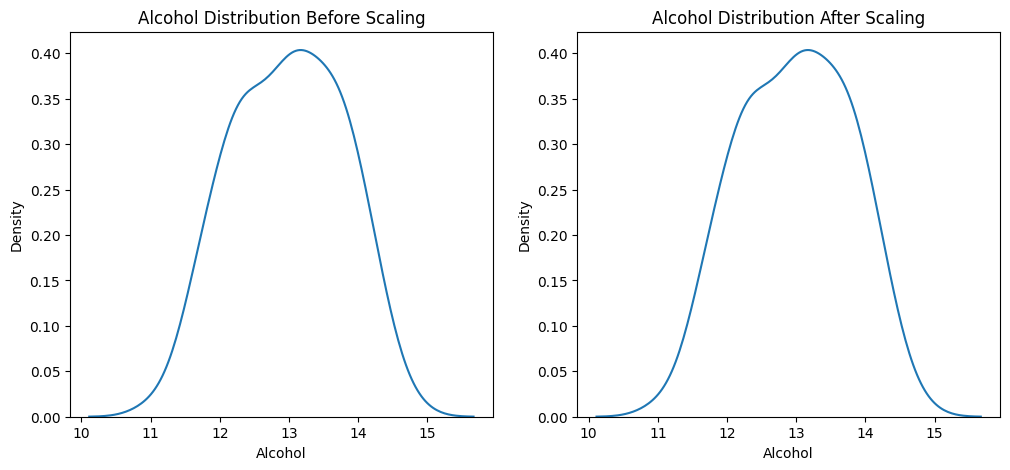

In [27]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(train_X['Alcohol'],ax=ax1)

ax2.set_title('Alcohol Distribution After Scaling')
sns.kdeplot(train_X['Alcohol'],ax=ax2)
plt.show()

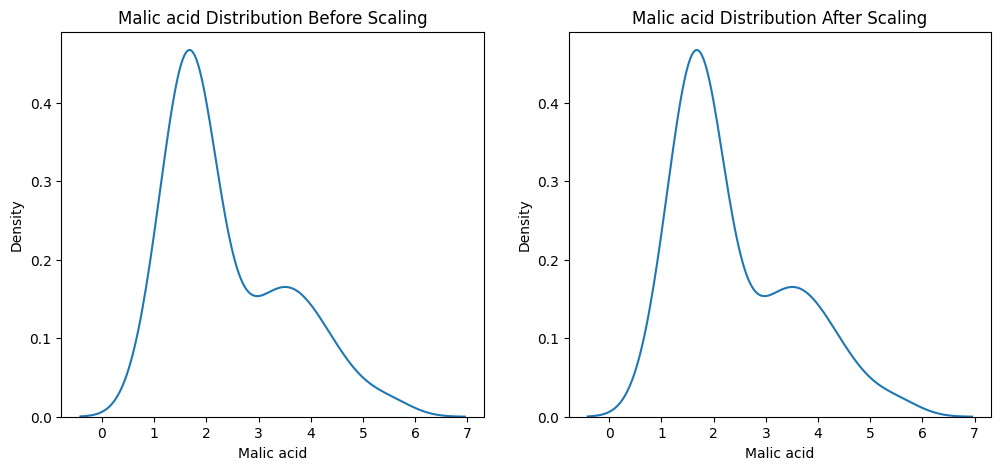

In [28]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(train_X['Malic acid'],ax=ax1)

ax2.set_title('Malic acid Distribution After Scaling')
sns.kdeplot(train_X['Malic acid'],ax=ax2)
plt.show()